# Semi Gradient n-step SARSA for Cartpole Domain

In [118]:
from mdp.base_config import BaseConfig
import numpy as np
import matplotlib.pyplot as plt
from mdp.cartpole.cartpole import CartPoleMDP
from algorithms.sgns_sarsa.n_step_sarsa_cp import NStepSarsaCP

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
base_config = BaseConfig(seed=42)

In [108]:
cartpole = CartPoleMDP(seed=42)
sarsa_agent = NStepSarsaCP(env=cartpole, base_config=base_config, gamma=1)

In [124]:
sarsa_agent.run(alpha=0.0005, num_episodes=5000, n_steps=3)

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

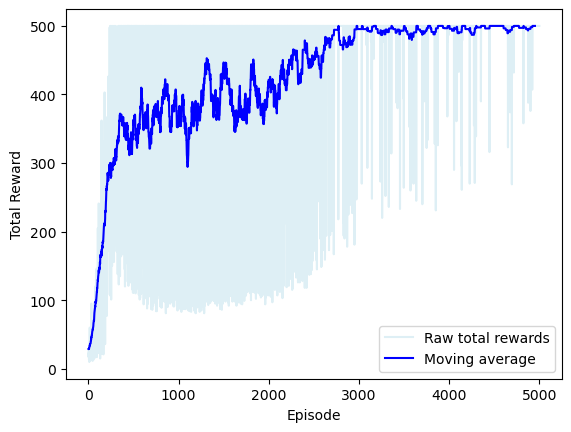

In [125]:
rewards = np.array(sarsa_agent.episode_rewards)
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.plot(rewards, color='lightblue', alpha=0.4, label='Raw total rewards')
plt.plot(smoothed, color='blue', label='Moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.show()

In [126]:
# Get average reward across all episodes
ep_rew = sarsa_agent.episode_rewards
average_reward = np.mean(ep_rew)
print(f'Average Reward over 1000 episodes: {average_reward}')

Average Reward over 1000 episodes: 425.8436


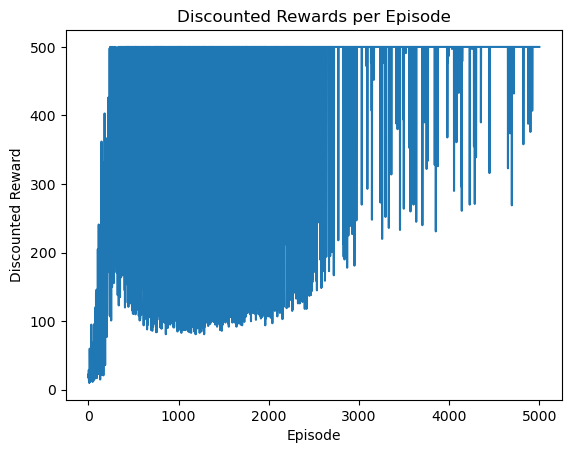

In [127]:
discounted_rewards = sarsa_agent.discounted_rewards
plt.plot(discounted_rewards)
plt.xlabel('Episode')
plt.ylabel('Discounted Reward')
plt.title('Discounted Rewards per Episode')
plt.show()

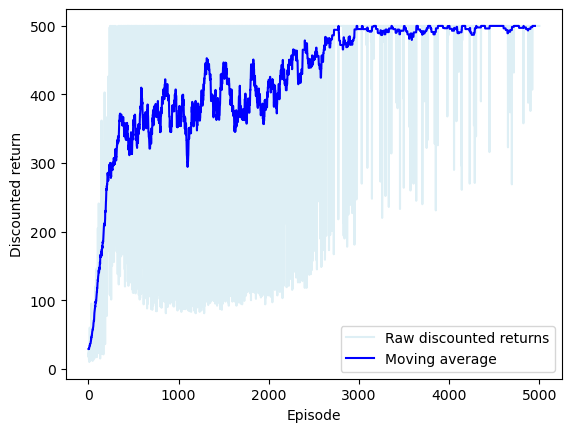

In [128]:
rewards = np.array(sarsa_agent.discounted_rewards)
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.plot(rewards, color='lightblue', alpha=0.4, label='Raw discounted returns')
plt.plot(smoothed, color='blue', label='Moving average')
plt.xlabel('Episode')
plt.ylabel('Discounted return')
plt.legend()
plt.show()

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

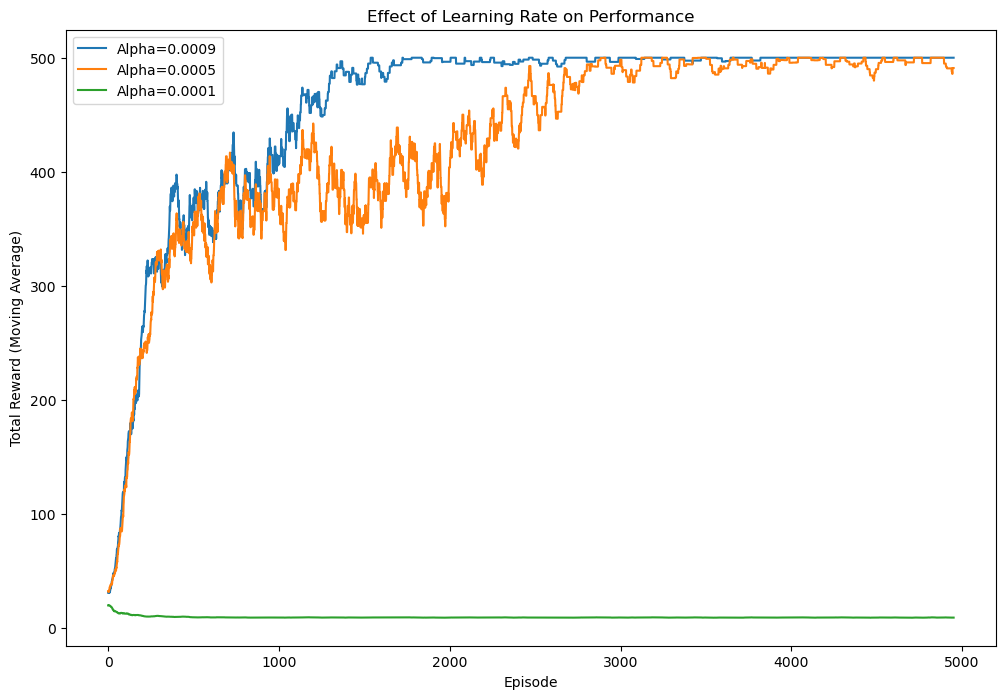

In [135]:
plt.figure(figsize=(12, 8))
alpha_vals = [0.0009, 0.0005, 0.0001]
for alpha in alpha_vals:
    cartpole = CartPoleMDP(seed=42)
    sarsa_agent = NStepSarsaCP(env=cartpole, base_config=base_config, gamma=1)
    sarsa_agent.run(alpha=alpha, num_episodes=5000, n_steps=3)

    rewards = np.array(sarsa_agent.episode_rewards)
    window = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    plt.plot(smoothed, label=f'Alpha={alpha}')

plt.xlabel('Episode')
plt.ylabel('Total Reward (Moving Average)')
plt.title('Effect of Learning Rate on Performance')
plt.legend()
plt.show()

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

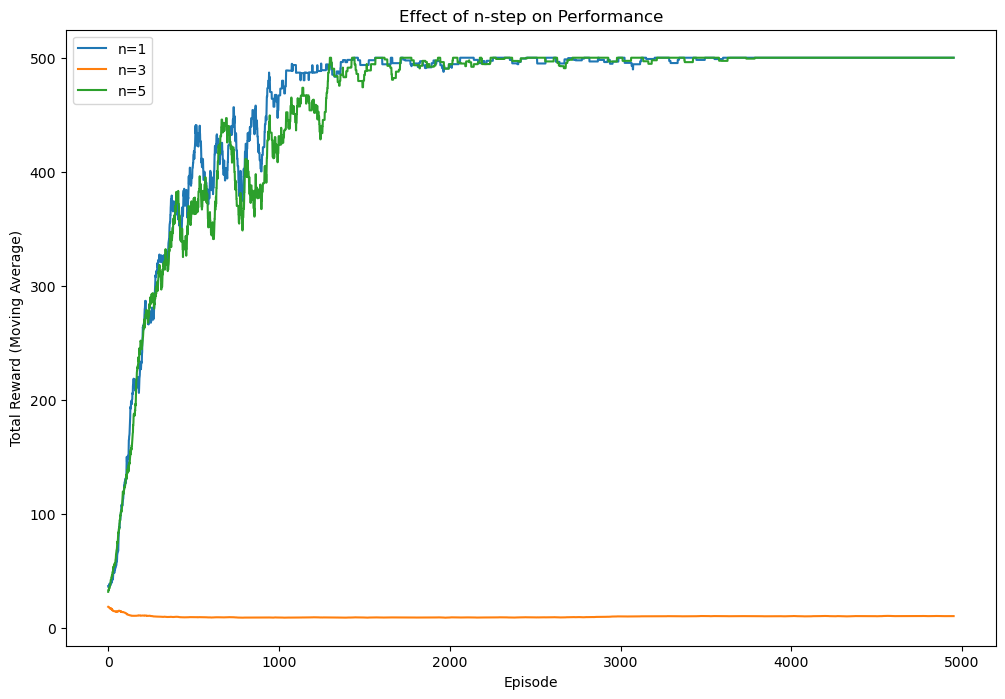

In [136]:
alpha = 0.0009
n_step_vals = [1, 3, 5]
plt.figure(figsize=(12, 8))
for n_steps in n_step_vals:
    cartpole = CartPoleMDP(seed=42)
    sarsa_agent = NStepSarsaCP(env=cartpole, base_config=base_config, gamma=1)
    sarsa_agent.run(alpha=alpha, num_episodes=5000, n_steps=n_steps)

    rewards = np.array(sarsa_agent.episode_rewards)
    window = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    plt.plot(smoothed, label=f'n={n_steps}')
plt.xlabel('Episode')
plt.ylabel('Total Reward (Moving Average)')
plt.title('Effect of n-step on Performance')
plt.legend()
plt.show()

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

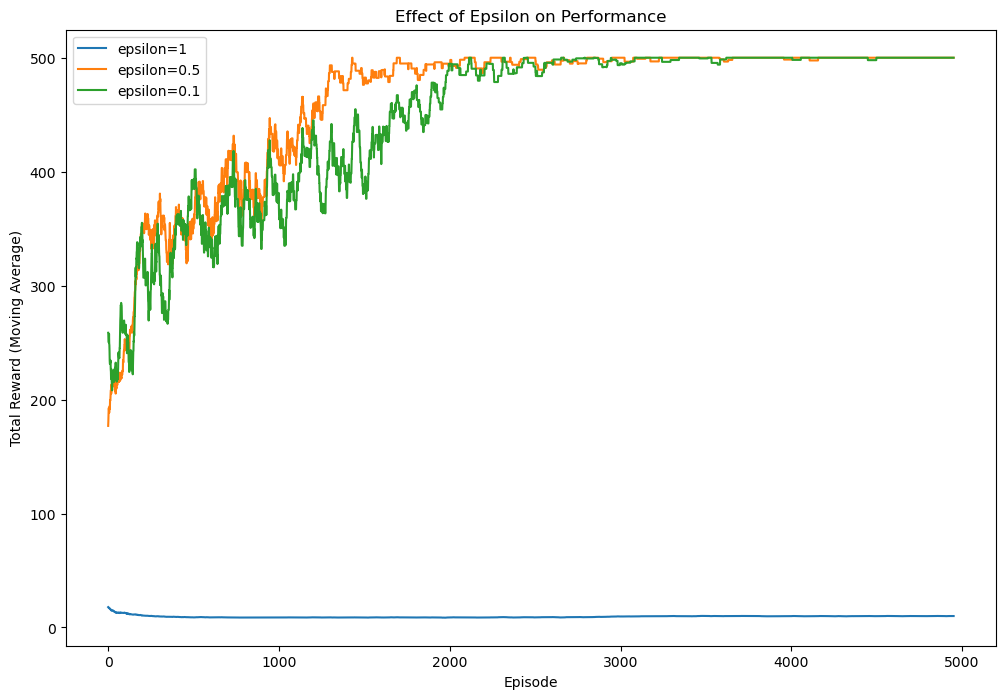

In [137]:
eps_vals = [1, 0.5, 0.1]
plt.figure(figsize=(12, 8))
for eps in eps_vals:
    cartpole = CartPoleMDP(seed=42)
    sarsa_agent = NStepSarsaCP(env=cartpole, base_config=base_config, gamma=1, epsilon=eps)
    sarsa_agent.run(alpha=alpha, num_episodes=5000, n_steps=3)

    rewards = np.array(sarsa_agent.episode_rewards)
    window = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    plt.plot(smoothed, label=f'epsilon={eps}')
plt.xlabel('Episode')
plt.ylabel('Total Reward (Moving Average)')
plt.title('Effect of Epsilon on Performance')
plt.legend()
plt.show()

Running SARSA Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

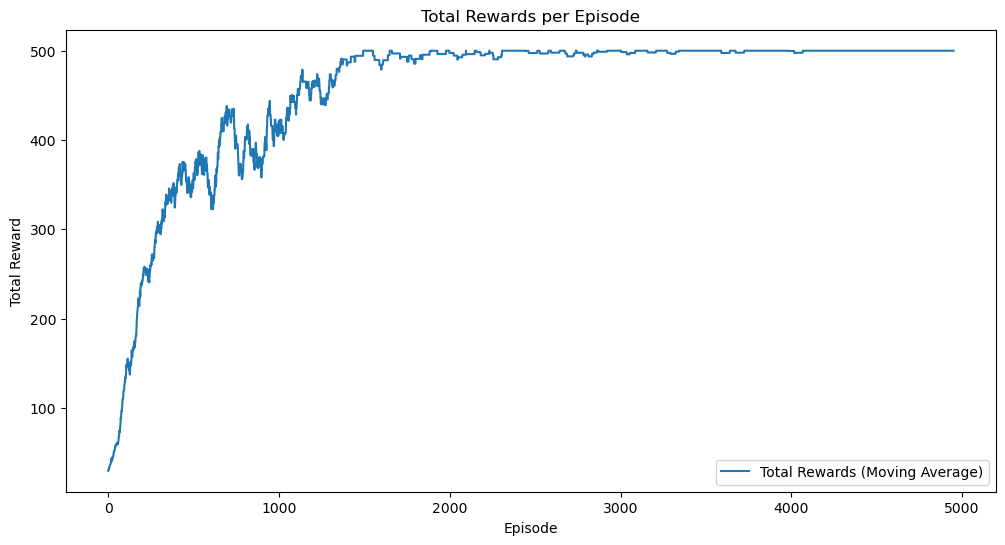

In [ ]:
# Final run
cartpole = CartPoleMDP(seed=42)
sarsa_agent = NStepSarsaCP(env=cartpole, base_config=base_config, gamma=1, epsilon=1)
sarsa_agent.run(alpha=0.0009, num_episodes=5000, n_steps=5)
ep_rewards = sarsa_agent.episode_rewards
discounted_rewards = sarsa_agent.discounted_rewards

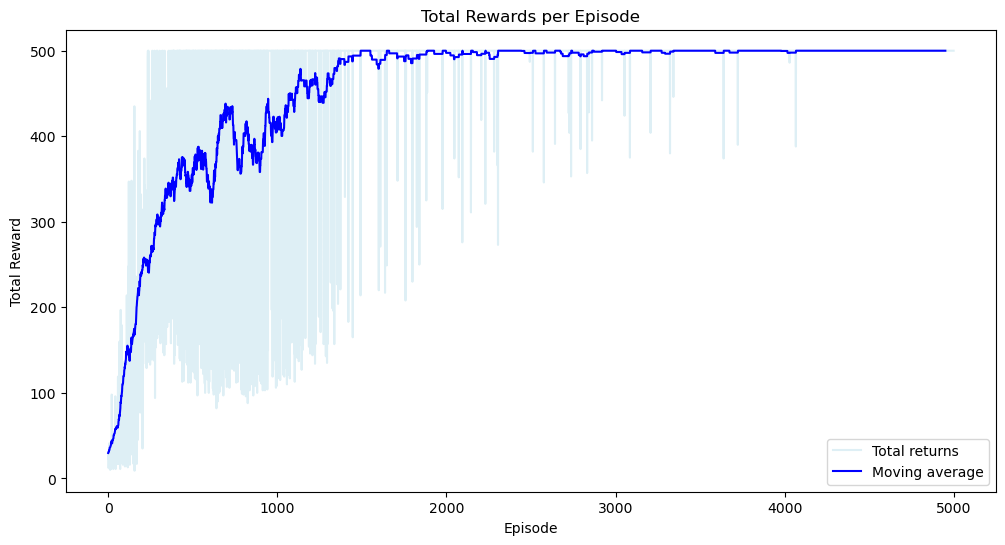

In [142]:
plt.figure(figsize=(12, 6))
rewards = np.array(ep_rewards)
window = 50
plt.plot(rewards, color='lightblue', alpha=0.4, label='Total returns')
plt.plot(smoothed, color='blue', label='Moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Rewards per Episode')
plt.legend()
plt.show()

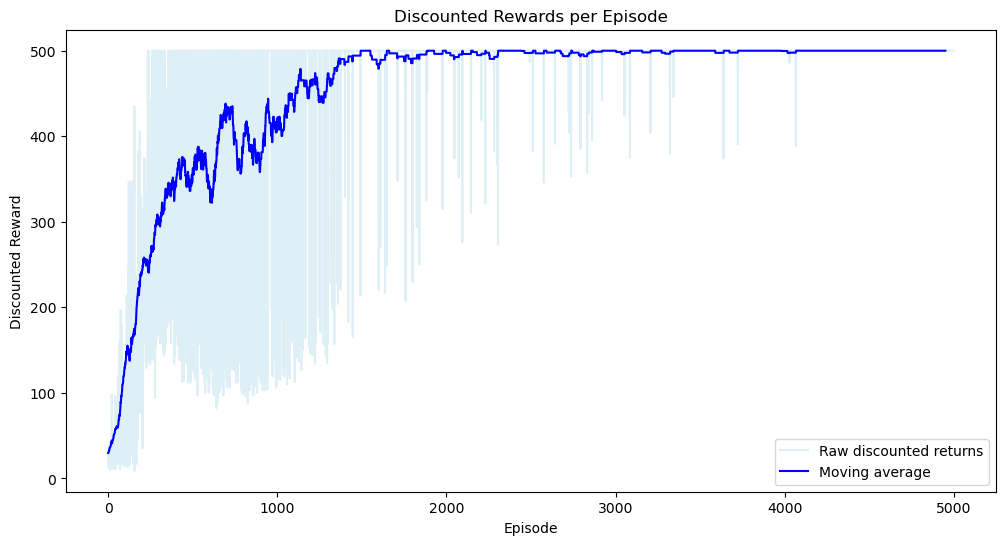

In [143]:
plt.figure(figsize=(12, 6))
rewards = np.array(discounted_rewards)
window = 50
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(rewards, color='lightblue', alpha=0.4, label='Raw discounted returns')
plt.plot(smoothed, color='blue', label='Moving average')
plt.xlabel('Episode')
plt.ylabel('Discounted Reward')
plt.title('Discounted Rewards per Episode')
plt.legend()
plt.show()